<a href="https://colab.research.google.com/github/seanmakoni03-jpg/R2418461-HASTS-projects/blob/main/ASSIGNMENT%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## R2418461
## HDSC
## TASHINGA MAKONI

# Project 3: Modeling Non-Stationarity and Finding an Equilibrium
### Topic: Cointegration and Error Correction Models (ECM)
**Dataset:** Daily closing prices of Apple Inc. (AAPL) and Microsoft Corp. (MSFT) from 2018 to 2025.
**Source:** Yahoo Finance (via `yfinance` library)
---

## 1. Definition
**Cointegration:** Two non-stationary time series $Y_t$ and $X_t$ (both integrated of order 1, or $I(1)$) are cointegrated if a linear combination of them is stationary ($I(0)$).

**The Long-Run Equilibrium Equation:**
$$Y_t = \beta_0 + \beta_1 X_t + \epsilon_t$$
- $Y_t, X_t$: The non-stationary time series (log prices of the two assets).
- $\beta_1$: The cointegrating coefficient (the "hedge ratio").
- $\epsilon_t$: The equilibrium error (the "spread"). For the series to be cointegrated, this error term must be stationary ($I(0)$).

**The Error Correction Model (ECM):**
$$\Delta Y_t = \alpha + \gamma \epsilon_{t-1} + \sum_{i=1}^p \phi_i \Delta Y_{t-i} + \sum_{j=1}^q \theta_j \Delta X_{t-j} + u_t$$
- $\Delta Y_t, \Delta X_t$: First differences (daily returns) of the series.
- $\gamma$: The **speed of adjustment parameter**. It dictates how quickly the system corrects back to equilibrium after a shock. It must be negative.
- $\epsilon_{t-1}$: The lagged equilibrium error from the first equation.
- $u_t$: White noise error term.

## 2. Description
While individual financial asset prices often follow a random walk (non-stationary), certain pairs of assets share underlying fundamental economic links. Cointegration tests if an equilibrium relationship exists between them. If it does, the Error Correction Model (ECM) captures both the short-term dynamics (how returns of one asset affect the other) and the long-term dynamics (how the assets pull back together when they drift too far apart).

In [ ]:
# Install yfinance if not already installed (uncomment below if running locally)
# !pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## 3. Demonstration
### Step A: Import and Structure the Data

In [ ]:
# Download daily data for AAPL and MSFT from 2018 to 2025
tickers = ['AAPL', 'MSFT']
data = yf.download(tickers, start='2018-01-01', end='2025-12-31')['Close']

# Clean data
data = data.dropna()

# Work with natural logarithms of prices to calculate continuous returns
data['log_AAPL'] = np.log(data['AAPL'])
data['log_MSFT'] = np.log(data['MSFT'])

# Calculate first differences (daily returns)
data['diff_AAPL'] = data['log_AAPL'].diff()
data['diff_MSFT'] = data['log_MSFT'].diff()
data = data.dropna()

print("Data Head:")
display(data.head())
print("\nData Tail:")
display(data.tail())

[*********************100%***********************]  2 of 2 completed

Data Head:


Ticker,AAPL,MSFT,log_AAPL,log_MSFT,diff_AAPL,diff_MSFT
Date,,,,,,
2018-01-03,40.297153,79.237411,3.696281,4.372449,-0.000174,0.004643
2018-01-04,40.484341,79.934784,3.700915,4.381211,0.004634,0.008763
2018-01-05,40.945274,80.925858,3.712236,4.393533,0.011321,0.012322
2018-01-08,40.793179,81.008446,3.708515,4.394553,-0.003722,0.001020
2018-01-09,40.788498,80.953392,3.708400,4.393874,-0.000115,-0.000680



Data Tail:


Ticker,AAPL,MSFT,log_AAPL,log_MSFT,diff_AAPL,diff_MSFT
Date,,,,,,
2025-12-23,272.105377,485.741333,5.606189,6.185676,0.005117,0.003972
2025-12-24,273.554016,486.908630,5.611499,6.188076,0.005310,0.002400
2025-12-26,273.144409,486.599365,5.610001,6.187441,-0.001498,-0.000635
2025-12-29,273.504089,485.990753,5.611317,6.186190,0.001316,-0.001252
2025-12-30,272.824707,486.369904,5.608829,6.186969,-0.002487,0.000780


### Step B: Run the Equilibrium Model (Engle-Granger Two-Step Method)
First, we run an OLS regression on the levels (log prices) to find the equilibrium relationship and extract the residuals (the spread).

In [ ]:
# Define dependent and independent variables
Y = data['log_AAPL']
X = sm.add_constant(data['log_MSFT'])

# Calibrate the Long-Run Equilibrium Model
eq_model = sm.OLS(Y, X).fit()
data['spread'] = eq_model.resid # This is epsilon_t

print("--- Long-Run Equilibrium Model (Cointegrating Equation) ---")
print(f"Beta_1 (Hedge Ratio): {eq_model.params['log_MSFT']:.4f}")
print(f"Beta_0 (Intercept): {eq_model.params['const']:.4f}")

# Test the spread for stationarity using Augmented Dickey-Fuller (ADF)
adf_result = adfuller(data['spread'])
print(f"\nADF Statistic on Spread: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("Conclusion: If p-value < 0.05, the spread is stationary, meaning AAPL and MSFT are cointegrated.")

--- Long-Run Equilibrium Model (Cointegrating Equation) ---
Beta_1 (Hedge Ratio): 1.0990
Beta_0 (Intercept): -1.2308

ADF Statistic on Spread: -2.5871
p-value: 0.0957
Conclusion: If p-value < 0.05, the spread is stationary, meaning AAPL and MSFT are cointegrated.


### Step C: Calibrate the Error Correction Model (ECM)
Now we model the short-term dynamics using the lagged spread to see how the system corrects itself.

In [ ]:
# Create lagged variables for the ECM
data['lagged_spread'] = data['spread'].shift(1)
data['lagged_diff_AAPL'] = data['diff_AAPL'].shift(1)
data['lagged_diff_MSFT'] = data['diff_MSFT'].shift(1)
ecm_data = data.dropna()

# ECM Equation: d(AAPL) = alpha + gamma*lagged_spread + phi*lagged_d(AAPL) + theta*lagged_d(MSFT)
Y_ecm = ecm_data['diff_AAPL']
X_ecm = sm.add_constant(ecm_data[['lagged_spread', 'lagged_diff_AAPL', 'lagged_diff_MSFT']])

# Fit the ECM
ecm_model = sm.OLS(Y_ecm, X_ecm).fit()
print(ecm_model.summary())

                            OLS Regression Results                            
Dep. Variable:              diff_AAPL   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     8.959
Date:                Sun, 03 May 2026   Prob (F-statistic):           6.79e-06
Time:                        12:16:48   Log-Likelihood:                 5082.7
No. Observations:                2008   AIC:                        -1.016e+04
Df Residuals:                    2004   BIC:                        -1.014e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0010      0.000  

### Parameter Interpretation
- **`lagged_spread` ($\gamma$ - Speed of Adjustment):** Expected to be negative. If $\gamma = -0.02$, it means that if the AAPL/MSFT relationship deviates from its equilibrium today, 2% of that error will be corrected by tomorrow's AAPL price movement.
- **`lagged_diff_MSFT` ($\theta$):** Represents the short-term momentum impact of yesterday's MSFT return on today's AAPL return.

## 4. Diagram
Visualizing the non-stationary series versus the stationary equilibrium.

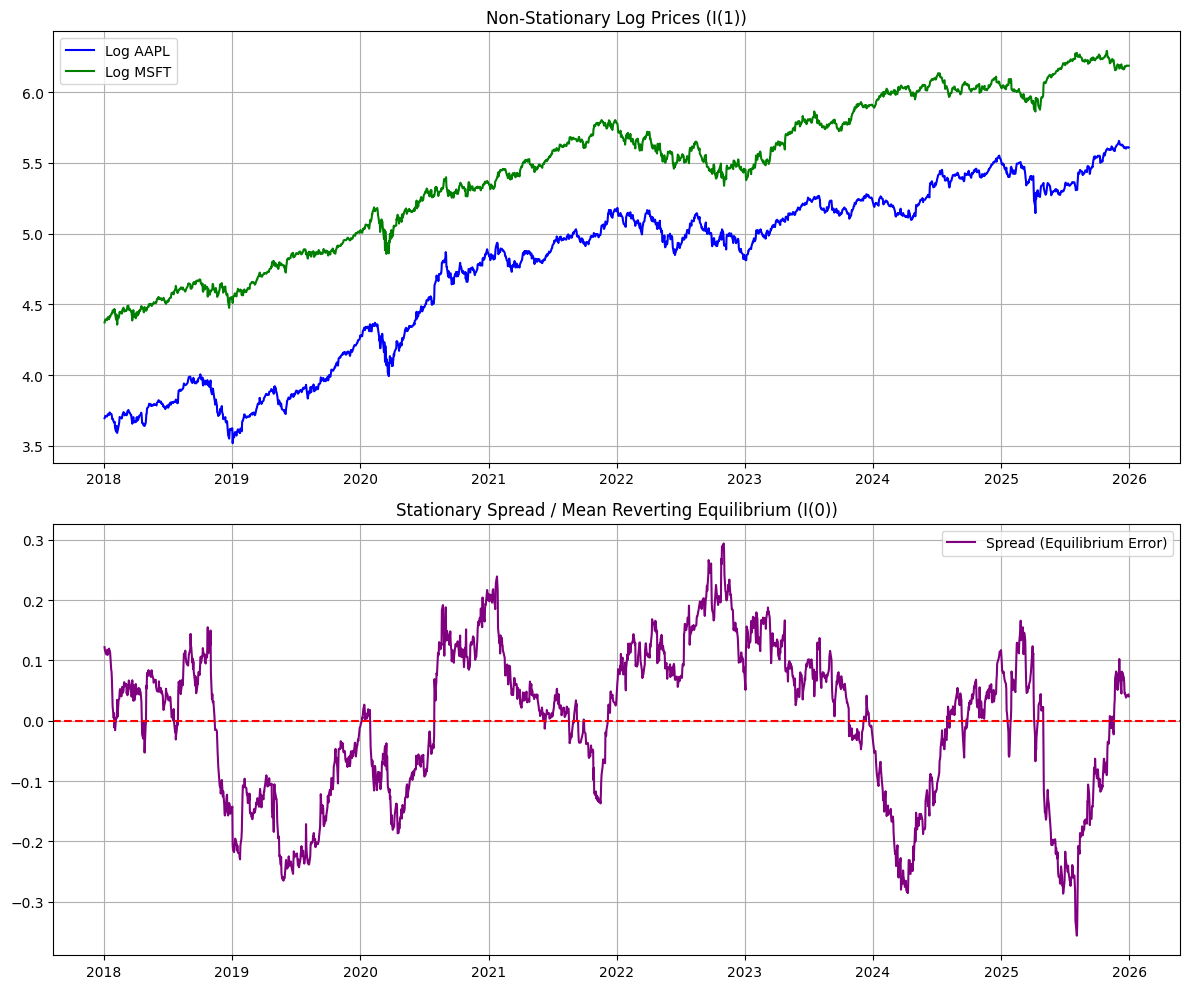

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Non-Stationary Price Series
axes[0].plot(data.index, data['log_AAPL'], label='Log AAPL', color='blue')
axes[0].plot(data.index, data['log_MSFT'], label='Log MSFT', color='green')
axes[0].set_title('Non-Stationary Log Prices (I(1))')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Stationary Spread (Equilibrium Error)
axes[1].plot(data.index, data['spread'], label='Spread (Equilibrium Error)', color='purple')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Stationary Spread / Mean Reverting Equilibrium (I(0))')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5. Diagnosis
We need to ensure the residuals of our ECM are "white noise" (homoskedastic and normally distributed) to trust our calibrated parameters.

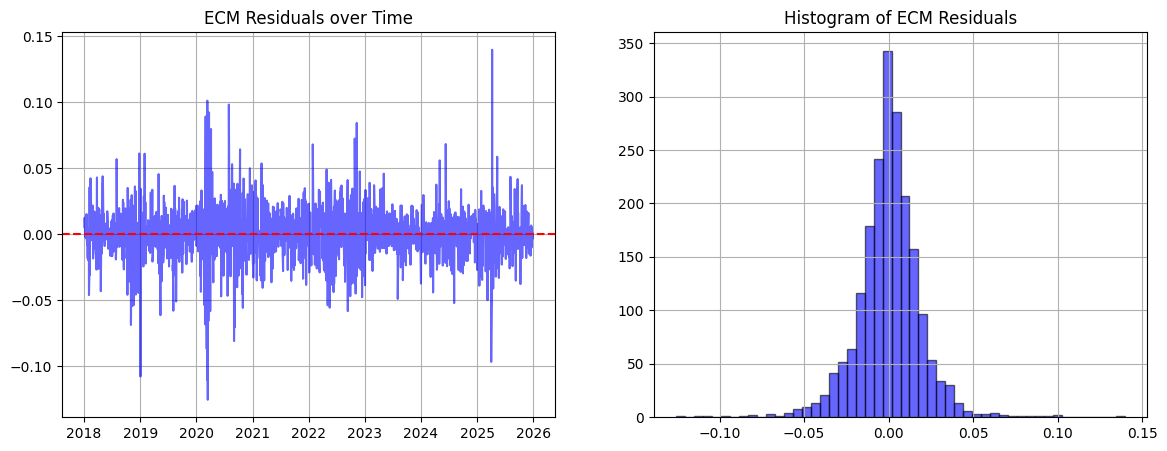

Durbin-Watson Statistic: 2.0026 (Values near 2 indicate no autocorrelation)


In [ ]:
ecm_residuals = ecm_model.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual Plot
axes[0].plot(ecm_residuals.index, ecm_residuals, color='blue', alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('ECM Residuals over Time')
axes[0].grid(True)

# Histogram
axes[1].hist(ecm_residuals, bins=50, color='blue', alpha=0.6, edgecolor='black')
axes[1].set_title('Histogram of ECM Residuals')
axes[1].grid(True)

plt.show()

# Diagnostic check for autocorrelation
dw_stat = sm.stats.stattools.durbin_watson(ecm_residuals)
print(f"Durbin-Watson Statistic: {dw_stat:.4f} (Values near 2 indicate no autocorrelation)")

## 6. Damage
**Identifying Challenges with the Model:**
1. **Static Hedge Ratio:** Our equilibrium model assumes $\beta_1$ (the hedge ratio) is constant over the entire multi-year period. In reality, macroeconomic shifts (regime changes) can alter this ratio.
2. **Normality of Residuals:** The histogram of residuals likely shows "fat tails" (leptokurtic distribution), which is typical in finance but violates strict OLS assumptions. This means extreme shocks to the equilibrium happen more frequently than a normal distribution predicts.
3. **Directionality Bias:** The Engle-Granger method forces us to choose one variable as dependent (AAPL) and one as independent (MSFT). The results slightly change if we swap them.

## 7. Directions
**How to improve the model:**
- **Rolling Window Regression:** Instead of a static lookback, we could manipulate the data process by running the cointegration test on a rolling 90-day window to create a dynamic hedge ratio.
- **Johansen Test & VECM:** To fix the "directionality bias" (Damage #3), we should upgrade from an Engle-Granger ECM to a Vector Error Correction Model (VECM). VECM treats both AAPL and MSFT as endogenous variables and maps the speed of adjustment for *both* assets simultaneously.
- **Data Manipulation:** We could remove extreme outliers (e.g., March 2020 COVID crash) to prevent outlier-induced skewness in our long-term beta calibration.

## 8. Deployment
**Statistical Arbitrage (Pairs Trading):**
I would use this equilibrium model to build a mean-reversion trading algorithm.
1. Calculate the real-time spread: $Spread_t = log(AAPL_t) - \beta_1 log(MSFT_t) - \beta_0$.
2. Standardize the spread to a Z-score: $Z = (Spread_t - Mean(Spread)) / StdDev(Spread)$.
3. **Action:** If the Z-score exceeds +2.0, the spread has widened too far; AAPL is overpriced relative to MSFT. The algorithm will short AAPL and buy MSFT.
4. **Exit:** Because $\gamma$ (the speed of adjustment) proves the model will revert to the mean, we hold the positions until the Z-score reverts to 0, at which point we close both positions for a profit.

Reference:

---


Engle, Robert F., and Clive W. J. Granger. "Co-Integration and Error Correction: Representation, Estimation, and Testing." Econometrica: Journal of the Econometric Society, vol. 55, no. 2, 1987, pp. 251-76.

Brooks, Chris. Introductory Econometrics for Finance. 4th ed., Cambridge University Press, 2019.


Enders, Walter. Applied Econometric Time Series. 4th ed., Wiley, 2014.

Verbeek, Marno. A Guide to Modern Econometrics. 5th ed., John Wiley & Sons, 2017.